<a href="https://colab.research.google.com/github/orebe2003-glitch/AUI/blob/main/google_colab_files/04_Classification_of_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


### **AAIM Curse_Classification of Data Notebook A**
 By Dr. Karla Reyes



1. ## Logistic Regression class - Diagnosis

```
Class task #1: Modify the input data, using the data example of the class, choose 5 different features (name them in the output) and 10 different patients, as output print the features values (X and Y), and the probability of diabetes of a new patient.  
```



In [ ]:
#Suppose we want to diagnose a patient with diabetes based on their age, blood pressure, and body mass index (BMI)

import numpy as np
from sklearn.linear_model import LogisticRegression

# Define the data (Age, BP, BMI)
X = np.array([[25, 120, 25], [45, 140, 30], [55, 160, 35]])
y = np.array([0, 1, 1])

# Create a logistic regression object
logreg = LogisticRegression()

# Fit the model
logreg.fit(X, y)

# Predict the probability of diabetes for a new patient
new_patient = np.array([30, 130, 28]).reshape(1, -1) # Reshape to a 2D array
probability = logreg.predict_proba(new_patient)[0][1]

print("Probability of diabetes:", probability)

2. ## Decision tree - classifying patients

```
Class task #2: Analyze which feature (age, blood pressure, cholesterol, etc..) is the most important in making the classification decision. How could could you determine this experimentally?
Hint: use clf.feature_importances_ and interpret the values.
```

In [ ]:
#Suppose we want to classify patients as either healthy or diseased based on their age, blood pressure, and cholesterol levels, smoker [0=no, 1 =yes], alcohol consume [0=no, 1 =yes], .

import numpy as np
from sklearn.tree import DecisionTreeClassifier

# Define the data
X = np.array([[25, 110, 180, 0 , 1 , 9], [35, 130, 190, 1 , 0 , 17], [45, 140, 200, 1, 0, 16],[21, 181, 210, 0, 1, 3],[15, 100, 200, 1, 1, 2]])
y = np.array([0, 0, 1, 1, 1]) # Healthy = 0, Diseased = 1

# Create a decision tree classifier
clf = DecisionTreeClassifier(max_depth=2)

# Fit the model
clf.fit(X, y)

# Predict the class for a new patient
new_patient = np.array([]).reshape(1,-1) #add mew patient features
prediction = clf.predict(new_patient)

print("Prediction:", prediction)


3. ## Prediction Accuracy by Decision Trees

```
# Class Task #3: Load Ovarian cancer data "Data1.csv". The purpose is to build a tree with training data and apply the test data to the same learned tree and calculate the prediction accuracy.
```

In [8]:
# Importing the libraries
from sklearn import tree
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

This data set contain 216 subjects each of which presented with 100 quantified values (clinical Proteomics). Out of all the subjects, 121 are diagnosed as ovarian cancer and 95 are healthy subjects. Therefore, it is binary classification and the class labels are set as -1 and +1.

In [5]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
import pandas as pd

# Reading the data (features and labels)
data = pd.read_csv('/content/drive/MyDrive/Data1.csv', header=None)
x = data.values[:, :100]
y = data.values[:, 100]

OSError: [Errno 107] Transport endpoint is not connected: '/content/drive/MyDrive/Data1.csv'

In [10]:
# Splitting the data into train and test
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=0)

In [11]:
# Compiling a tree
tree_depth = 2
clf = tree.DecisionTreeClassifier(criterion='entropy', max_depth=tree_depth , random_state=0)

# Learning the compiled tree with training data
clf = clf.fit(x_train, y_train)

In [14]:
#  predict the class labels of test data set using "clf.predict"
y_pred = clf.predict(x_test)

# Find the accuracy of the model by comparing the achieved class labels and real labels.
test_acc = accuracy_score(y_test, y_pred)


#### Effect of tree depth on the model performance

In [18]:
d_depth = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]  # Add a list of different depths, i.e. 1,2,3,....20 to determinate wich depth one has better performance
for d in d_depth:
    clf = tree.DecisionTreeClassifier(criterion='entropy', max_depth=d , random_state=0)
    clf = clf.fit(x_train, y_train)
    y_pred = clf.predict(x_test)
    test_acc = accuracy_score(y_test, y_pred)
    print('Test accuracy with depth of {} is {}'.format(d, test_acc))

Test accuracy with depth of 1 is 0.7727272727272727
Test accuracy with depth of 2 is 0.7727272727272727
Test accuracy with depth of 3 is 0.8409090909090909
Test accuracy with depth of 4 is 0.8181818181818182
Test accuracy with depth of 5 is 0.8181818181818182
Test accuracy with depth of 6 is 0.8181818181818182
Test accuracy with depth of 7 is 0.8181818181818182
Test accuracy with depth of 8 is 0.8181818181818182
Test accuracy with depth of 9 is 0.8181818181818182
Test accuracy with depth of 10 is 0.8181818181818182
Test accuracy with depth of 11 is 0.8181818181818182
Test accuracy with depth of 12 is 0.8181818181818182
Test accuracy with depth of 13 is 0.8181818181818182
Test accuracy with depth of 14 is 0.8181818181818182
Test accuracy with depth of 15 is 0.8181818181818182
Test accuracy with depth of 16 is 0.8181818181818182
Test accuracy with depth of 17 is 0.8181818181818182
Test accuracy with depth of 18 is 0.8181818181818182
Test accuracy with depth of 19 is 0.8181818181818182
Te

4. ## Binary Classification with kNN

```
# Class Task #4: Follow the TODO in the code and write the answers in a word document
```

In [19]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


In [20]:
# Importing the required libraries.
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set()

 We start with a simple example of two class classification problem. The dataset contains 569 subjects from each 30 features were extracted and labeled as 1 or 0 to present the malignant or benign breast cancer.

In [21]:
# Loading the data (features and labels)
cancer_breast = load_breast_cancer()
x = pd.DataFrame(cancer_breast.data, columns = cancer_breast.feature_names)
x = x[['mean area', 'mean compactness']]
y = pd.Categorical.from_codes(cancer_breast.target, cancer_breast.target_names)
y = pd.get_dummies(y, drop_first=True)

The model should be learned with training data, then, the performance of the learned model should be evaluated over the unseen test data.

In [22]:
# Splitting 25% of the data into train and the rest to the test sets.
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=1)

In [23]:
# Compiling the KNN model
n_neighbor = 3
knn = KNeighborsClassifier(n_neighbors = n_neighbor, metric='euclidean')
# Training the complied model with training data
knn.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(metric='euclidean', n_neighbors=3)

In [24]:
# Predicting the unseen data and quantify the model performance:
y_pred = knn.predict(x_test)
print('Prediction Accuracy Score is:',metrics.accuracy_score(y_test,y_pred))

Prediction Accuracy Score is: 0.8321678321678322


#### Visualization of the KNN Performance:
The dimension of the employed data set is 30. Therefore, for simplicity, we use only two features to visualize a 2D scatterplot of the datapoints compared against the predicted ones.

<Axes: xlabel='mean area', ylabel='mean compactness'>

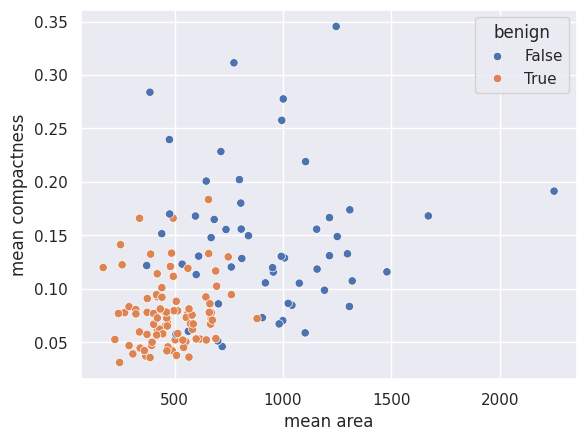

In [29]:
# Scatter plot of the prediction
plot_data = pd.concat([x_test, y_test], axis=1)
sns.scatterplot(
    x='mean area',
    y='mean compactness',
    hue='benign',
    data=plot_data)

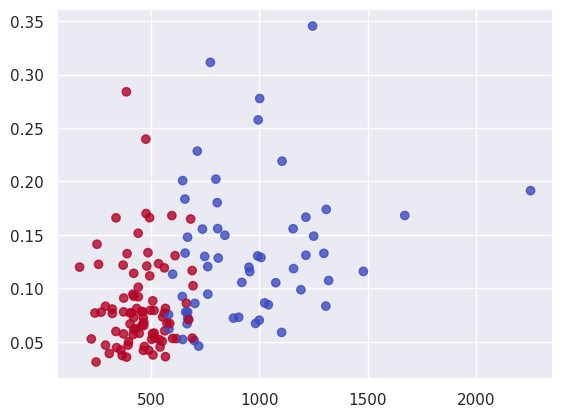

In [26]:
# Scatter plot of the real data
plt.scatter(
    x_test['mean area'],
    x_test['mean compactness'],
    c=y_pred,
    cmap='coolwarm',
    alpha=0.8)

### Changing the value of nearest neighbors and find out its effect!
To better understand how the value of nearest neighbor (K) affect the performance and generalization power
of the KNN model, we are going to train different KNN models with different K values.

In [31]:
k_val = [1, 2, 3, 4, 5, 6, 7, 8,9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] # Add a list of different NN, i.e. 1,2,3,....20 to determinate wich has better performance

for k in k_val:
    knn = KNeighborsClassifier(n_neighbors = k, metric='euclidean')
    knn.fit(x_train, y_train)
    y_pred = knn.predict(x_test)
    performance = metrics.accuracy_score(y_test,y_pred)
    print('Prediction performance of KNN with K of {} is {}'.format(k, performance))

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for 

Prediction performance of KNN with K of 1 is 0.7902097902097902
Prediction performance of KNN with K of 2 is 0.7902097902097902
Prediction performance of KNN with K of 3 is 0.8321678321678322
Prediction performance of KNN with K of 4 is 0.8041958041958042
Prediction performance of KNN with K of 5 is 0.8461538461538461
Prediction performance of KNN with K of 6 is 0.8321678321678322
Prediction performance of KNN with K of 7 is 0.8461538461538461
Prediction performance of KNN with K of 8 is 0.8251748251748252
Prediction performance of KNN with K of 9 is 0.8531468531468531
Prediction performance of KNN with K of 10 is 0.8321678321678322
Prediction performance of KNN with K of 11 is 0.8601398601398601
Prediction performance of KNN with K of 12 is 0.8531468531468531
Prediction performance of KNN with K of 13 is 0.8671328671328671
Prediction performance of KNN with K of 14 is 0.8531468531468531
Prediction performance of KNN with K of 15 is 0.8601398601398601
Prediction performance of KNN with

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for 

5. ## Binary classification with SVM

```
# Class Task #5: Follow the TODO in the code and write the answers in a word document
```

In [32]:
# importing the libraries
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import seaborn as sns; sns.set()

The purpose here is to define a line in 2D or a manifold in multi-dimensions to divide classes of the data. For instance, consider the following simple case of a 2D data set which are linearly separable.

In [33]:
data = pd.read_csv('/content/gdrive/MyDrive/Data0.csv', header=None)
X = data.values[:, :2]
y = data.values[:, 2]
plt.scatter(X[:, 0], X[:, 1], c=y, s=60, cmap='viridis');

FileNotFoundError: [Errno 2] No such file or directory: '/content/Data0.csv'

In this simple example, there are two classes highlighted with different colors. The classes do not have overlap and therefore you can even use a linear equation to separate them from each other..

 However, the problem is that there are unlimited number of such lines that are able to separate the classes. Based on which lines you choose,  a new data point will be either below or above the line and will be assigned to one of the classes. (Look at the point marked by "X" in the following plot).

In [ ]:
xfit = np.linspace(-0.5, 3)
plt.scatter(X[:, 0], X[:, 1], c=y, s=60, cmap='viridis')

# The following script draws a line by following the equation "Y-y0 = m(X-x0)"
# on the data plane. Please note the value inside each of the parentheses
# represent the parameters of 'm' and 'b' of the equation.
for m, b in [(-0.67, 2.2), (-1.5,2.5)]:
    plt.plot(xfit, m * xfit + b, '-k')

plt.plot([2.5],[0],'X',color='red', markeredgewidth=1, markersize=8)

plt.xlim(-0.5, 3);

# TODO: Try different sepparating lines by modifing m,b
# TODO: Was the point "X" assigned to the same class when you used different separating line?

It would be possible that the new data point was assigned to a different class based on the line you draw. One way to address such problems is to use two separating lines instead of only one line and maximize the distance between the two separating lines (maximize the margins). In fact, using only one line for separation is like to use two lines with a zero-width of margin. Therefore, we can add a margin between the separating lines and the line that maximizes this margin can be selected as an optimal line in SVM algorithm.

In [ ]:
from sklearn.datasets import make_blobs # Importing make_blobs from the correct module
X, y = make_blobs(n_samples=50, centers=2,random_state=0, cluster_std=0.60)
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=60, cmap='viridis')

# Comparing to the previous lines, here another parameter "d" is added.
# The parameter 'd' works as a bias to move the lines up and down.
# The following parameters of 'd' inside the parentheses are found experimentally.
# What SVM does, is finding the such parameters automatically.

for m, b, d in [ (0.5, 1.6, 0.6), (-0.2, 2.9, 0.2)]:
    yfit = m * xfit + b
    plt.plot(xfit, yfit, '-k')
    plt.fill_between(xfit, yfit - d, yfit + d, edgecolor='none',
                     color='#AAAAAA', alpha=0.6)

plt.xlim(-1, 3.5);

# TODO: Change the parameters 'd' inside the parentheses (0.6 and 0.2) and
# notice how it would change the margins. Please note the margins should not, optimally,
# include any data.

Now, instead of finding the line and margin width manually, we are going to train a model by using a linear SVM to find the optimal parameters.

In [ ]:
from sklearn.svm import SVC # "Support vector classifier"
model = SVC(kernel='linear', C=1E10)  # Set the linear kernel and a large value of C
model.fit(X, y) # Fitting the data set to the model

In [ ]:
# To understand what SVM does, it is better to visualize how it find the decision boundary.
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='r',
               levels=[-1, 0, 1], alpha=0.8,
               linestyles=['--', '-', '--'])

    # plot the support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=500, linewidth=10, facecolor='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

In [ ]:
# Plotting the data point distributions:
plt.scatter(X[:, 0], X[:, 1], c=y, s=60, cmap='viridis')
# Drawing the decision boundaries.
plot_svc_decision_function(model);

In the plot above, there is one solid line (main separating line) and two dashed-lines (margins). Any other lines will have less values of margin than the one above. Some of the training data points in this plot are placed exactly on the margin lines. In other words, margin lines passed through the middle of these points. These important points are called "Support Vectors" :

In [ ]:
# Finding the exact number of Support Vectors.
n_support = model.support_vectors_
print('The number of support vector is: {}'.format(len(n_support)))

The number of support vector is: 3


In SVMs, finding the optimum separating line  depends on the position (coordinates) of these Support Vectors. Other points further from the margins are in the correct sides and do not effect the fitting procedure. That is because these points do not contribute to the loss function used to fit the model, so their position and their frequency do not matter as long as they do not cross the margin. We can observe such behavior, for example, if we plot the model learned from the first 70 points and, then, first 140 points of this dataset:

In [ ]:
def plot_svm(N=10, ax=None):
    X, y = make_blobs(n_samples=200, centers=2,
                      random_state=0, cluster_std=0.60)
    X = X[:N]
    y = y[:N]
    model = SVC(kernel='linear', C=1E10)
    model.fit(X, y)

    ax = ax or plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=y, s=60, cmap='viridis')
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 6)
    plot_svc_decision_function(model, ax)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)
for axi, N in zip(ax, [70, 140]):
    plot_svm(N, axi)
    axi.set_title('N = {0}'.format(N))

The above two figures depict that SVM model fits the line using only Support Vectors and the model is not sensitive to other data points. In fact, the left figure contains half of the data points of the right figure, but both of them have the same separating lines because both of them have similar Support Vectors.

In [ ]:
# Changing the number of the data points and interpret the results.
from ipywidgets import interact, fixed
interact(plot_svm, N=[8,10,20,50,100,150,180,300,500,2000], ax=fixed(None));

What about non-linear separable data set?

In [ ]:
from sklearn.datasets import make_circles  # Load input data
X, y = make_circles(50, factor=.1, noise=0.2)

Model1 = SVC(kernel='linear').fit(X, y) # Fit a linear SVM

# Plot the data points distribution using the "plt.scatter"
plt.scatter(X[:, 0], X[:, 1], c=y, s=60, cmap='viridis')

# Call the function "plot_svc_decision_function" to draw the decision boundaries.
plot_svc_decision_function(Model1);

# TODO: Run this cell several times (workbook excercise 5.4);

Are the drawn lines able to properly separate the classes? why?

One practical way to handle nonlinear separable data set is to use "Kernel Trick". This means we can project our data set to a higher dimension space where the data points are linearly separable. There are different functions for this projection such as Gaussian (Radial) basis function and polynomials. In other words, we map a nonlinear separable data set into a higher dimension space, artificially, then within the new space linear separation would be sufficient.

In [ ]:
# TODO: Run and play with the angles (workbook excercise 5.5)
r = np.exp(-(X ** 2).sum(1))
from mpl_toolkits import mplot3d

def plot_3D(elev=30, azim=30, X=X, y=y):
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=60, cmap='viridis')
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('r')

interact(plot_3D, elev=[-90,-60,0,30,90], azip=(-180,180),
         X=fixed(X), y=fixed(y));

If you want to separate the two classes in a higher dimenstion linearly, which line will you use?
(workbook 5.6)

### Training a Kernel-based SVM

In [ ]:
Model2 = SVC(kernel='rbf', C=1E6) # Creating an SVM with Radial Basis Function
Model2.fit(X, y)

In [ ]:
# Plotting the data points distribution using the "plt.scatter"
plt.scatter(X[:, 0], X[:, 1], c=y, s=60, cmap='viridis')

# Call the function "plot_svc_decision_function" to draw the decision boundaries.
plot_svc_decision_function(Model2)

Soft Margin SVMs: So far we have seen data set with a clear decision boundary; however, in real cases data points from different classes often overlapping each other:

In [ ]:
# Example of dataset with class overlapping
X, y = make_blobs(n_samples=200, centers=2,random_state=0, cluster_std=1.2)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='viridis');
# TODO: Is it possible to use linear or even kernel based SVM to classify these data? (workbook 5.6)

In previous examples there were a parameter "C" which we set it as a very large number. The role of this parameter is to prevent the data points from appearing inside the margins. The larger this value the lower the chance of data points inside the margins. Accordingly, if we do not allow any points to appear inside the margins we have a "Hard Margin SVM" like what we did in previous examples. On the other hand, we can allow the margins to be softer to contain some of the data points.

In [ ]:
# Comparison of soft and hard margin SVM.
X, y = make_blobs(n_samples=100, centers=2,random_state=0, cluster_std=0.8) # Input Data

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

for axi, C in zip(ax, [10.0, 0.1]):
    model = SVC(kernel='linear', C=C).fit(X, y)
    axi.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='viridis')
    plot_svc_decision_function(model, axi)
    axi.scatter(model.support_vectors_[:, 0],
                model.support_vectors_[:, 1],
                s=300, lw=1, facecolors='none');
    axi.set_title('C = {0:.1f}'.format(C), size=14)

# TODO: How do you compare these two figures? (workbook 5.7)

6. ###  Random Forrest

The same ovarian cancer data will be used to train a Random Forest.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Reading the data (features and labels)
data = pd.read_csv('/content/Data1.csv', header=None)
x = data.values[:, :100]
y = data.values[:, 100]

# Splitting the data into train and test
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=0)

In [ ]:
# Compiling a Random Forest model
criterion = 'gini' # 'gini' or 'entropy'
max_depth = None
random_state = 42
rf_clf = RandomForestClassifier(criterion = criterion,
                            max_depth = max_depth,
                            random_state = random_state)

In [ ]:
# Learning the compiled RF with training data
rf_clf.fit(x_train, y_train)
# Predicting the labels of unseen data

y_pred_rf = rf_clf.predict(x_test)
test_acc_rf = accuracy_score(y_test, y_pred_rf)

In [ ]:
print('Test accuray of RF model is: {}'.format(test_acc_rf))